# Nock Noun Space Exploration

Systematic evaluation of every Nock 4K formula up to size 4 (leaf-atom count),
with all atom values 0–11, against a fixed subject corpus.

**Metrics per evaluation:** validity · crash reason · result type / size / depth · step count

| Formula size | Tree shapes | Formulas (atoms 0–11) |
|:---:|:---:|---:|
| 2 | 1 | 144 |
| 3 | 2 | 3,456 |
| 4 | 5 | 103,680 |

**Subjects:** atoms 0–11 plus 5 small cells = 17 total.

In [13]:
# ── Parameters — edit here, then Kernel → Restart & Run All ─────────────────

ATOM_RANGE     = range(12)    # atom values at every leaf (0..N-1); covers all opcodes when N >= 12
SWEEP_SIZES    = [2, 3, 4, 5, 6]    # formula leaf-counts to sweep  (size 4 ≈ 1.76 M evals, ~1 min)

CHUNK_SIZE     = 50_000       # rows flushed to disk at a time — keep low to bound peak RAM
MEM_LIMIT_ROWS = 5_000_000    # load into pandas if row count <= this; otherwise use DuckDB

## 0. Setup

In [14]:
import sys, os, itertools
from pathlib import Path

_pinochle = Path.home() / 'urbit/tarpit/pinochle/packages/pinochle'
if str(_pinochle) not in sys.path:
    sys.path.insert(0, str(_pinochle))

import subprocess
for _pkg in ('pandas', 'matplotlib', 'tqdm', 'pyarrow'):
    try:
        __import__(_pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', _pkg])

import importlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pinochle.noun import Cell, deep
from pinochle.nock import to_noun
# importlib bypasses the __init__.py name-shadowing issue:
# pinochle.__init__ does `from .nock import nock`, which overwrites
# pinochle.__dict__['nock'] with the function, so plain
# `import pinochle.nock as x` would give the function via IMPORT_FROM.
_nock_module = importlib.import_module('pinochle.nock')

print('pinochle:', _nock_module.__file__)

pinochle: /Users/neal/urbit/tarpit/pinochle/packages/pinochle/pinochle/nock.py


## 1. Instrumentation

Replace `pinochle.nock.nock` with a thin counter wrapper.  Internal recursive
calls inside the original function body use `LOAD_GLOBAL` on the module dict,
so they automatically route through the wrapper — **no upstream changes required**.

The cell is idempotent: re-running it does not double-wrap.

In [15]:
if not hasattr(_nock_module, '_patched'):
    _orig = _nock_module.nock

    class _Ctr:
        n = 0

    def _wrap(a, formula):
        _Ctr.n += 1
        return _orig(a, formula)

    _nock_module.nock = _wrap
    _nock_module._patched = True
    _nock_module._ctr = _Ctr
else:
    _Ctr = _nock_module._ctr


def nock_counted(subject, formula):
    """Evaluate nock(subject, formula).
    Returns (result_or_None, steps, error_str_or_None).
    """
    _Ctr.n = 0
    try:
        result = _nock_module.nock(subject, formula)
        return result, _Ctr.n, None
    except RecursionError:
        return None, _Ctr.n, 'recursion_limit'
    except Exception as e:
        return None, _Ctr.n, str(e)


# Sanity checks
_r, _s, _e = nock_counted(0, to_noun((1, 42)))
assert (_r, _s, _e) == (42, 1, None), f'opcode 1 constant: got {(_r, _s, _e)}'

_r, _s, _e = nock_counted(41, to_noun((4, (0, 1))))
assert (_r, _s, _e) == (42, 2, None), f'opcode 4 incr: got {(_r, _s, _e)}'

_r, _s, _e = nock_counted(0, 0)
assert _r is None and _e is not None, 'atom formula should crash'

print('Instrumentation OK — sanity checks passed')
print(f'  [1 42] on subject 0 -> result={nock_counted(0, to_noun((1, 42)))[0]}, steps=1')
print(f'  [4 0 1] on subject 41 -> result={nock_counted(41, to_noun((4,(0,1))))[0]}, steps=2')

Instrumentation OK — sanity checks passed
  [1 42] on subject 0 -> result=42, steps=1
  [4 0 1] on subject 41 -> result=42, steps=2


## 2. Noun Utilities

- `all_shapes(n)` — Catalan(n−1) full binary tree shapes (nested `None`-tuples)
- `all_nouns(size, atom_range)` — yields `(shape_idx, noun)` for every noun with `size` leaves
- `noun_size / noun_depth` — iterative to avoid Python recursion limit on large results
- `opcode_of(formula)` — head atom, `-1` for the distribution rule, `None` for atom formula

In [16]:
def all_shapes(n):
    """All full binary tree shapes with n leaves.  Count = Catalan(n-1)."""
    if n == 1:
        yield None
        return
    for k in range(1, n):
        for left in all_shapes(k):
            for right in all_shapes(n - k):
                yield (left, right)


def _fill(shape, it):
    """Fill shape with atoms from iterator it, depth-first left-to-right."""
    if shape is None:
        return next(it)
    return Cell(_fill(shape[0], it), _fill(shape[1], it))


def all_nouns(size, atom_range=range(12)):
    """Yield (shape_idx, noun) for all nouns with `size` leaves."""
    shapes = list(all_shapes(size))
    for shape_idx, shape in enumerate(shapes):
        for atoms in itertools.product(atom_range, repeat=size):
            yield shape_idx, _fill(shape, iter(atoms))


def noun_size(n, cap=10_000):
    """Count leaves, capped at `cap` to guard against huge results."""
    stack, count = [n], 0
    while stack:
        node = stack.pop()
        if deep(node):
            stack.append(node.head)
            stack.append(node.tail)
        else:
            count += 1
            if count >= cap:
                return cap
    return count


def noun_depth(n):
    """Maximum depth (root = 0), iterative."""
    if not deep(n):
        return 0
    max_d, stack = 0, [(n, 0)]
    while stack:
        node, d = stack.pop()
        if deep(node):
            stack.append((node.head, d + 1))
            stack.append((node.tail, d + 1))
        elif d > max_d:
            max_d = d
    return max_d


def noun_str(n, limit=60):
    s = str(n) if deep(n) else str(n)
    return s if len(s) <= limit else s[:limit] + '...'


def opcode_of(formula):
    """Head atom (-1 for distribution rule, None for atom formula)."""
    if not deep(formula):
        return None
    h = formula.head
    return -1 if deep(h) else int(h)


# Verify Catalan numbers
for _n, _exp in [(2, 1), (3, 2), (4, 5), (5, 14)]:
    _got = sum(1 for _ in all_shapes(_n))
    assert _got == _exp, f'all_shapes({_n}) = {_got}, expected {_exp}'

print('Shape counts: ' + ', '.join(
    f'size {n} -> {sum(1 for _ in all_shapes(n))}' for n in range(2, 6)
))

# Quick noun generation check
_test = [(si, n) for si, n in all_nouns(2, range(3))]
assert len(_test) == 9, f'size-2 over 0..2 should be 9 nouns, got {len(_test)}'
print('Noun generation OK')

Shape counts: size 2 -> 1, size 3 -> 2, size 4 -> 5, size 5 -> 14
Noun generation OK


## 3. Corpus

**Subjects:** 12 atoms (0–11) + 5 small cells.
**Formulas:** all nouns of sizes 2–4 with atoms 0–11.

In [17]:
SUBJECTS = []
for _i in range(12):
    SUBJECTS.append({'label': str(_i), 'noun': _i, 'stype': 'atom'})
for _lbl, _tup in [
    ('[0 0]',     (0, 0)),
    ('[0 1]',     (0, 1)),
    ('[1 0]',     (1, 0)),
    ('[0 [0 1]]', (0, (0, 1))),
    ('[[0 1] 0]', ((0, 1), 0)),
]:
    SUBJECTS.append({'label': _lbl, 'noun': to_noun(_tup), 'stype': 'cell'})

_N = len(ATOM_RANGE)
print(f'ATOM_RANGE = range({ATOM_RANGE.start}, {ATOM_RANGE.stop})  ({_N} values)')
print(f'SWEEP_SIZES = {SWEEP_SIZES}')
print(f'Subjects: {len(SUBJECTS)}')
for _sz in SWEEP_SIZES:
    _shapes = list(all_shapes(_sz))
    _nf  = len(_shapes) * (_N ** _sz)
    _tot = _nf * len(SUBJECTS)
    print(
        f'  Size {_sz}: {len(_shapes)} shape(s) x {_N}^{_sz}'
        f' = {_nf:>9,} formulas  x  {len(SUBJECTS)} subjects'
        f' = {_tot:>12,} evals'
    )

ATOM_RANGE = range(0, 12)  (12 values)
SWEEP_SIZES = [2, 3, 4, 5, 6]
Subjects: 17
  Size 2: 1 shape(s) x 12^2 =       144 formulas  x  17 subjects =        2,448 evals
  Size 3: 2 shape(s) x 12^3 =     3,456 formulas  x  17 subjects =       58,752 evals
  Size 4: 5 shape(s) x 12^4 =   103,680 formulas  x  17 subjects =    1,762,560 evals
  Size 5: 14 shape(s) x 12^5 = 3,483,648 formulas  x  17 subjects =   59,222,016 evals
  Size 6: 42 shape(s) x 12^6 = 125,411,328 formulas  x  17 subjects = 2,131,992,576 evals


## 4. Sweep

One row per `(subject, formula)` pair.  Results are saved to Parquet so
analysis cells can be re-run without re-evaluating.

In [18]:
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm import tqdm

# Fixed schema keeps ParquetWriter happy across chunks.
_SCHEMA = pa.schema([
    ('subject', pa.string()),
    ('stype',   pa.string()),
    ('formula', pa.string()),
    ('fsize',   pa.int64()),
    ('fshape',  pa.int64()),
    ('opcode',  pa.int64()),
    ('valid',   pa.bool_()),
    ('error',   pa.string()),
    ('rtype',   pa.string()),
    ('rsize',   pa.int64()),
    ('rdepth',  pa.int64()),
    ('result',  pa.string()),
    ('steps',   pa.int64()),
])


def sweep(sizes, save_path=None):
    """Evaluate all (subject, formula) pairs.
    Rows are flushed to disk every CHUNK_SIZE evals so peak RAM stays bounded
    regardless of how many total rows are generated.
    Returns total row count written.
    """
    writer = pq.ParquetWriter(save_path, _SCHEMA) if save_path else None
    rows = []
    total_written = 0

    def _flush():
        nonlocal total_written
        if not rows:
            return
        arrays = {k: [r[k] for r in rows] for k in _SCHEMA.names}
        writer.write_table(pa.table(arrays, schema=_SCHEMA))
        total_written += len(rows)
        rows.clear()

    try:
        for size in sizes:
            shapes  = list(all_shapes(size))
            n_forms = len(shapes) * len(ATOM_RANGE) ** size
            total   = n_forms * len(SUBJECTS)
            print(f'Size {size}: {n_forms:,} formulas x {len(SUBJECTS)} subjects = {total:,} evals')
            pbar = tqdm(total=total, desc=f'size {size}')
            for shape_idx, formula in all_nouns(size, ATOM_RANGE):
                opc  = opcode_of(formula)
                fstr = noun_str(formula)
                for subj in SUBJECTS:
                    result, steps, error = nock_counted(subj['noun'], formula)
                    if result is not None:
                        rtype  = 'atom' if not deep(result) else 'cell'
                        rsize  = noun_size(result)
                        rdepth = noun_depth(result)
                        rstr   = noun_str(result)
                    else:
                        rtype, rsize, rdepth, rstr = 'crash', 0, 0, ''
                    rows.append({
                        'subject': subj['label'],
                        'stype':   subj['stype'],
                        'formula': fstr,
                        'fsize':   size,
                        'fshape':  shape_idx,
                        'opcode':  opc,
                        'valid':   error is None,
                        'error':   error or '',
                        'rtype':   rtype,
                        'rsize':   rsize,
                        'rdepth':  rdepth,
                        'result':  rstr,
                        'steps':   steps,
                    })
                    if save_path and len(rows) >= CHUNK_SIZE:
                        _flush()
                    pbar.update(1)
            pbar.close()
        _flush()
    finally:
        if writer:
            writer.close()

    print(f'Total: {total_written:,} rows -> {save_path}')
    return total_written


def _save_path():
    return f"nock_a{len(ATOM_RANGE)}_s{'_'.join(str(s) for s in SWEEP_SIZES)}.parquet"

In [7]:
n_written = sweep(SWEEP_SIZES, save_path=_save_path())
print(f'Sweep complete: {n_written:,} rows in {_save_path()}')

Size 2: 144 formulas x 17 subjects = 2,448 evals


size 2: 100%|███████████████████████████| 2448/2448 [00:00<00:00, 569950.39it/s]


Size 3: 3,456 formulas x 17 subjects = 58,752 evals


size 3: 100%|█████████████████████████| 58752/58752 [00:00<00:00, 357004.97it/s]


Size 4: 103,680 formulas x 17 subjects = 1,762,560 evals


...

Size 5: 3,483,648 formulas x 17 subjects = 59,222,016 evals


size 5: 100%|███████████████████| 59222016/59222016 [02:51<00:00, 345889.54it/s]


Size 6: 125,411,328 formulas x 17 subjects = 2,131,992,576 evals


size 6: 100%|█████████████| 2131992576/2131992576 [3:18:58<00:00, 178580.08it/s]


Total: 2,193,038,352 rows -> nock_a12_s2_3_4_5_6.parquet
Sweep complete: 2,193,038,352 rows in nock_a12_s2_3_4_5_6.parquet


In [19]:
# Load results for analysis.  Run this cell instead of the sweep cell above
# when the parquet file already exists and you only want to re-run analysis.
import duckdb

try:
    import subprocess, sys
    __import__('duckdb')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'duckdb'])
    import duckdb

_path  = _save_path()
_meta  = pq.read_metadata(_path)
_nrows = _meta.num_rows
_mb    = os.path.getsize(_path) / 1e6
print(f'{_path}:  {_nrows:,} rows,  {_mb:.0f} MB on disk')

if _nrows <= MEM_LIMIT_ROWS:
    df  = pd.read_parquet(_path)
    ddb = duckdb.connect()
    ddb.execute("SET enable_progress_bar = false")
    ddb.register('results', df)
    print(f'Loaded into pandas df ({len(df):,} rows); also registered as ddb table "results"')
else:
    df  = None
    ddb = duckdb.connect()
    ddb.execute("SET enable_progress_bar = false")
    ddb.execute(f"CREATE VIEW results AS SELECT * FROM read_parquet('{_path}')")
    print(f'Too large for pandas ({_nrows:,} rows > MEM_LIMIT_ROWS={MEM_LIMIT_ROWS:,}).')
    print('df is None — use ddb for analysis.  Examples:')
    print('  ddb.sql("SELECT opcode, COUNT(*) n FROM results GROUP BY 1 ORDER BY 1").df()')
    print('  ddb.sql("SELECT * FROM results WHERE valid ORDER BY steps DESC LIMIT 20").df()')

nock_a12_s2_3_4_5_6.parquet:  2,193,038,352 rows,  1287 MB on disk
Too large for pandas (2,193,038,352 rows > MEM_LIMIT_ROWS=5,000,000).
df is None — use ddb for analysis.  Examples:
  ddb.sql("SELECT opcode, COUNT(*) n FROM results GROUP BY 1 ORDER BY 1").df()
  ddb.sql("SELECT * FROM results WHERE valid ORDER BY steps DESC LIMIT 20").df()


In [20]:
# DuckDB summary — works whether df is loaded into pandas or not.
OPC_NAMES = {
     0: 'fas (axis)',    1: 'constant',   2: 'eval',
     3: 'cell?',         4: 'incr',       5: 'equal?',
     6: 'if-then-else',  7: 'compose',    8: 'extend',
     9: 'invoke',       10: 'replace',   11: 'hint',
    -1: 'distribute',
}

_summary = ddb.sql("""
    SELECT
        opcode,
        COUNT(*)                                                            AS count,
        ROUND(100.0 * SUM(CASE WHEN valid     THEN 1 ELSE 0 END) / COUNT(*), 1) AS valid_pct,
        ROUND(AVG(steps), 2)                                                AS mean_steps,
        MAX(steps)                                                          AS max_steps,
        ROUND(100.0 * SUM(CASE WHEN rtype='cell' THEN 1 ELSE 0 END) / COUNT(*), 1) AS cell_result_pct
    FROM results
    GROUP BY opcode
    ORDER BY opcode
""").df()
_summary['name'] = _summary['opcode'].map(lambda i: OPC_NAMES.get(int(i), '?'))
print(f'Total rows: {_summary["count"].sum():,}')
print(_summary[['opcode', 'name', 'count', 'valid_pct', 'mean_steps', 'max_steps', 'cell_result_pct']].to_string(index=False))

Total rows: 2,193,038,352
 opcode         name      count  valid_pct  mean_steps  max_steps  cell_result_pct
     -1   distribute 1460486592        0.2        3.45         10              0.2
      0   fas (axis)   61045980        0.0        1.00          1              0.0
      1     constant   61045980      100.0        1.00          1            100.0
      2         eval   61045980        0.0        2.74          9              0.0
      3        cell?   61045980        3.3        3.86         10              0.0
      4         incr   61045980        0.2        3.86         10              0.0
      5       equal?   61045980        0.1        2.74          9              0.0
      6 if-then-else   61045980        0.0        3.11          8              0.0
      7      compose   61045980        0.1        2.74          9              0.1
      8       extend   61045980        0.2        2.74          9              0.1
      9       invoke   61045980        0.0        2.80       

## 5. Analysis

### 5a. Summary Statistics

### 5b. Validity Rate by Opcode

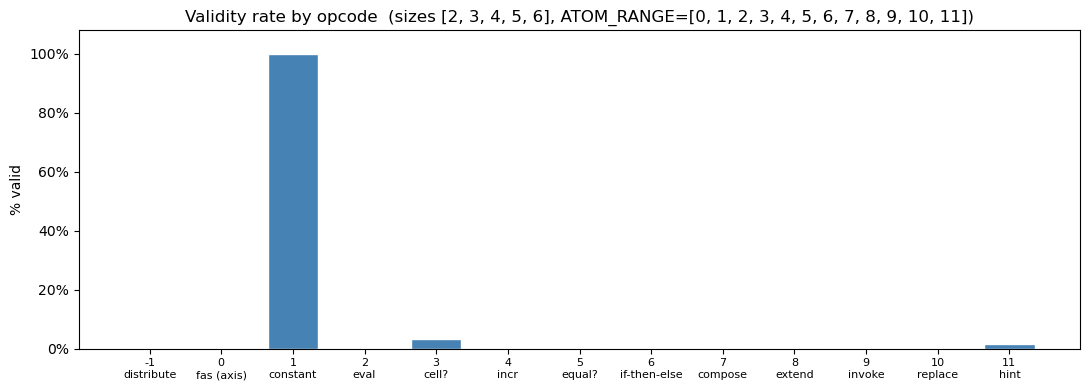

In [21]:
_vbo = ddb.sql("""
    SELECT opcode,
           COUNT(*) AS total,
           SUM(CASE WHEN valid THEN 1 ELSE 0 END) AS valid_n
    FROM results
    GROUP BY opcode ORDER BY opcode
""").df()
_vbo['pct'] = 100 * _vbo['valid_n'] / _vbo['total']
_vbo['opcode'] = _vbo['opcode'].astype(int)

fig, ax = plt.subplots(figsize=(11, 4))
_x = _vbo['opcode'].tolist()
ax.bar(_x, _vbo['pct'], color='steelblue', edgecolor='white', width=0.7)
ax.set_xticks(_x)
ax.set_xticklabels([f'{i}\n{OPC_NAMES.get(i, "?")}' for i in _x], fontsize=8)
ax.set_ylabel('% valid')
ax.set_ylim(0, 108)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title(f'Validity rate by opcode  (sizes {SWEEP_SIZES}, ATOM_RANGE={list(ATOM_RANGE)})')
plt.tight_layout()
plt.show()

### 5c. Error Breakdown

In [22]:
_err = ddb.sql("""
    SELECT opcode, error, COUNT(*) AS count
    FROM results
    WHERE NOT valid
    GROUP BY opcode, error
    ORDER BY opcode, count DESC
""").df()
_err['name'] = _err['opcode'].map(lambda i: OPC_NAMES.get(int(i), str(i)))
print(_err[['opcode', 'name', 'error', 'count']].head(50).to_string(index=False))

 opcode         name                                      error     count
     -1   distribute                                 fail: atom 771753192
     -1   distribute              crash: invalid formula (atom) 562557241
     -1   distribute           fas: first argument must be atom  69029537
     -1   distribute Opcode 10 requires [b c] as first argument  46008576
     -1   distribute                                       fail   7002276
     -1   distribute                                 fail: cell   1664006
      0   fas (axis)           fas: first argument must be atom  61045776
      0   fas (axis)                                 fail: atom       156
      0   fas (axis)                                       fail        17
      2         eval              crash: invalid formula (atom)  36695280
      2         eval                                 fail: atom  21408292
      2         eval           fas: first argument must be atom   1532221
      2         eval Opcode 10 require

### 5d. Shape vs. Validity

In [23]:
_sizes = ddb.sql("SELECT DISTINCT fsize FROM results ORDER BY fsize").df()['fsize'].tolist()
_shapes_by_size = {n: list(all_shapes(n)) for n in _sizes}

for _sz in _sizes:
    _sv = ddb.sql(f"""
        SELECT fshape,
               COUNT(*) AS total,
               SUM(CASE WHEN valid THEN 1 ELSE 0 END) AS valid_n
        FROM results WHERE fsize = {_sz}
        GROUP BY fshape ORDER BY fshape
    """).df()
    _sv['pct'] = 100 * _sv['valid_n'] / _sv['total']
    print(f'\nSize {_sz}:')
    for _, _row in _sv.iterrows():
        _shape = str(_shapes_by_size[_sz][int(_row['fshape'])])
        print(
            f'  shape {int(_row["fshape"])}  {_shape:38s}'
            f'  {_row["pct"]:5.1f}% valid'
            f'  ({int(_row["valid_n"])}/{int(_row["total"])})'
        )


Size 2:
  shape 0  (None, None)                              9.6% valid  (235/2448)

Size 3:
  shape 0  (None, (None, None))                      9.9% valid  (2911/29376)
  shape 1  ((None, None), None)                      0.0% valid  (0/29376)

Size 4:
  shape 0  (None, (None, (None, None)))             10.1% valid  (35576/352512)
  shape 1  (None, ((None, None), None))              8.3% valid  (29376/352512)
  shape 2  ((None, None), (None, None))              0.9% valid  (3281/352512)
  shape 3  ((None, (None, None)), None)              0.0% valid  (0/352512)
  shape 4  (((None, None), None), None)              0.0% valid  (0/352512)

Size 5:
  shape 0  (None, (None, (None, (None, None))))     10.2% valid  (429386/4230144)
  shape 1  (None, (None, ((None, None), None)))      9.0% valid  (381888/4230144)
  shape 2  (None, ((None, None), (None, None)))      8.7% valid  (365912/4230144)
  shape 3  (None, ((None, (None, None)), None))      8.3% valid  (352512/4230144)
  shape 4  (None

### 5e. Result Type Distribution by Opcode

In [24]:
_rt = ddb.sql("""
    SELECT opcode,
           SUM(CASE WHEN rtype='atom'  THEN 1 ELSE 0 END) AS atom,
           SUM(CASE WHEN rtype='cell'  THEN 1 ELSE 0 END) AS cell,
           SUM(CASE WHEN rtype='crash' THEN 1 ELSE 0 END) AS crash
    FROM results
    GROUP BY opcode ORDER BY opcode
""").df()
_rt = _rt.set_index(
    _rt['opcode'].map(lambda i: f'{int(i):>3}: {OPC_NAMES.get(int(i), "?"):<16}')
)
print(_rt[['atom', 'cell', 'crash']].to_string())

                           atom        cell         crash
opcode                                                   
-1: distribute              0.0   2471764.0  1.458015e+09
 0: fas (axis)             24.0         7.0  6.104595e+07
 1: constant              204.0  61045776.0  0.000000e+00
 2: eval                 3389.0       446.0  6.104214e+07
 3: cell?             2034167.0         0.0  5.901181e+07
 4: incr                96688.0         0.0  6.094929e+07
 5: equal?              83859.0         0.0  6.096212e+07
 6: if-then-else         7872.0       384.0  6.103772e+07
 7: compose             49492.0     36297.0  6.096019e+07
 8: extend              54110.0     40779.0  6.095109e+07
 9: invoke               7303.0      3572.0  6.103510e+07
10: replace              3168.0       407.0  6.104240e+07
11: hint               119640.0    776280.0  6.015006e+07


### 5f. Result Size & Depth Distribution

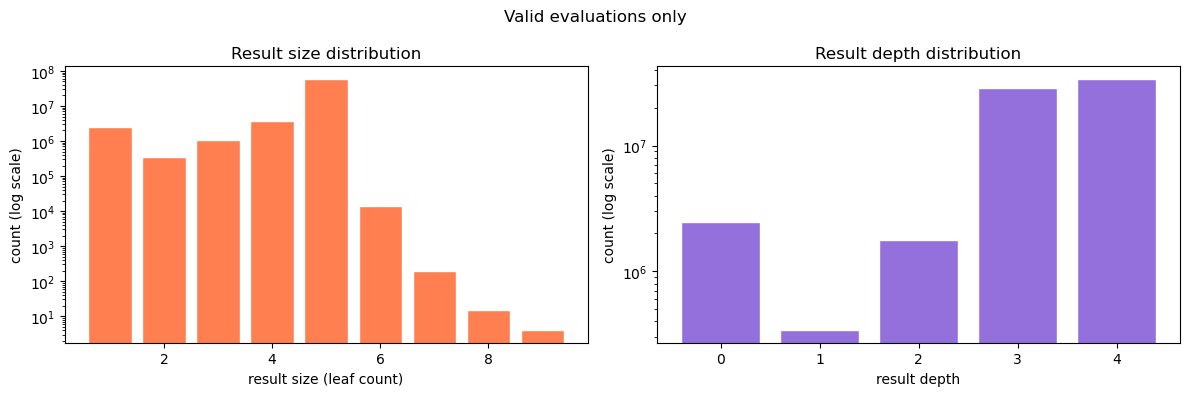


Top 10 by result size:
  subject           formula  opcode  rsize  rdepth                        result
[0 [0 1]] [[[0 1] 0 1] 0 1]      -1      9       4       [[[0 0 1] 0 0 1] 0 0 1]
[[0 1] 0] [[[0 1] 0 1] 0 1]      -1      9       4 [[[[0 1] 0] [0 1] 0] [0 1] 0]
[0 [0 1]] [[0 1] [0 1] 0 1]      -1      9       4       [[0 0 1] [0 0 1] 0 0 1]
[[0 1] 0] [[0 1] [0 1] 0 1]      -1      9       4 [[[0 1] 0] [[0 1] 0] [0 1] 0]
[0 [0 1]]   [9 1 [0 3] 0 3]       9      8       3       [[[0 1] 0 1] [0 1] 0 1]
[[0 1] 0] [[[0 2] 0 1] 0 1]      -1      8       4     [[[0 1] [0 1] 0] [0 1] 0]
    [0 1]   [9 1 [0 1] 0 1]       9      8       3       [[[0 1] 0 1] [0 1] 0 1]
[[0 1] 0]   [9 1 [0 2] 0 2]       9      8       3       [[[0 1] 0 1] [0 1] 0 1]
[[0 1] 0] [[[0 1] 0 1] 0 2]      -1      8       4     [[[[0 1] 0] [0 1] 0] 0 1]
[[0 1] 0] [[[0 1] 0 2] 0 1]      -1      8       4     [[[[0 1] 0] 0 1] [0 1] 0]


In [25]:
_rsizes = ddb.sql("""
    SELECT rsize, COUNT(*) AS n FROM results
    WHERE valid AND rsize > 0
    GROUP BY rsize ORDER BY rsize
""").df()

_rdepths = ddb.sql("""
    SELECT rdepth, COUNT(*) AS n FROM results
    WHERE valid AND rsize > 0
    GROUP BY rdepth ORDER BY rdepth
""").df()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(_rsizes['rsize'], _rsizes['n'], color='coral', edgecolor='white', width=0.8)
axes[0].set_yscale('log')
axes[0].set_xlabel('result size (leaf count)')
axes[0].set_ylabel('count (log scale)')
axes[0].set_title('Result size distribution')

axes[1].bar(_rdepths['rdepth'], _rdepths['n'], color='mediumpurple', edgecolor='white', width=0.8)
axes[1].set_yscale('log')
axes[1].set_xlabel('result depth')
axes[1].set_ylabel('count (log scale)')
axes[1].set_title('Result depth distribution')

plt.suptitle('Valid evaluations only')
plt.tight_layout()
plt.show()

print('\nTop 10 by result size:')
print(ddb.sql("""
    SELECT subject, formula, opcode, rsize, rdepth, result
    FROM results ORDER BY rsize DESC LIMIT 10
""").df().to_string(index=False))

### 5g. Fixed-Point Search

Cases where the result equals the subject or equals the formula
(compared as pretty-printed strings — the result truncation at 60 chars
means very long results may be missed, but all short ones are found).

In [26]:
_n_fp_s = ddb.sql("SELECT COUNT(*) FROM results WHERE valid AND result = subject").fetchone()[0]
print(f'result == subject: {_n_fp_s:,} cases')
if _n_fp_s:
    print(ddb.sql("""
        SELECT subject, formula, opcode, rtype, steps FROM results
        WHERE valid AND result = subject LIMIT 15
    """).df().to_string(index=False))

_n_fp_f = ddb.sql("SELECT COUNT(*) FROM results WHERE valid AND result = formula").fetchone()[0]
print(f'\nresult == formula: {_n_fp_f:,} cases')
if _n_fp_f:
    print(ddb.sql("""
        SELECT subject, formula, opcode, rtype, steps FROM results
        WHERE valid AND result = formula LIMIT 15
    """).df().to_string(index=False))

result == subject: 153,982 cases
subject formula  opcode rtype  steps
      0   [0 1]       0  atom      1
      1   [0 1]       0  atom      1
      2   [0 1]       0  atom      1
      3   [0 1]       0  atom      1
      4   [0 1]       0  atom      1
      5   [0 1]       0  atom      1
      6   [0 1]       0  atom      1
      7   [0 1]       0  atom      1
      8   [0 1]       0  atom      1
      9   [0 1]       0  atom      1
     10   [0 1]       0  atom      1
     11   [0 1]       0  atom      1
  [0 0]   [0 1]       0  cell      1
  [0 1]   [0 1]       0  cell      1
  [1 0]   [0 1]       0  cell      1

result == formula: 4 cases
subject           formula  opcode rtype  steps
  [0 1]             [0 1]       0  cell      1
  [0 1]       [[0 1] 0 1]      -1  cell      3
  [0 1] [[0 1] [0 1] 0 1]      -1  cell      5
  [0 1] [[[0 1] 0 1] 0 1]      -1  cell      5


### 5h. Step-Count Analysis

In [27]:
print('Top 20 evaluations by step count:')
print(ddb.sql("""
    SELECT subject, formula, opcode, steps, valid, error, rtype, result
    FROM results ORDER BY steps DESC LIMIT 20
""").df().to_string(index=False))

Top 20 evaluations by step count:
  subject         formula  opcode  steps  valid                         error rtype  result
[[0 1] 0]   [9 1 9 2 0 1]       9     13  False crash: invalid formula (atom) crash        
[0 [0 1]] [9 1 [1 9] 0 1]       9     12  False                          fail crash        
[[0 1] 0] [9 1 [0 2] 0 1]       9     12  False crash: invalid formula (atom) crash        
[0 [0 1]]   [9 7 9 3 0 1]       9     11  False crash: invalid formula (atom) crash        
    [0 1]   [9 3 9 1 0 1]       9     11  False crash: invalid formula (atom) crash        
[[0 1] 0]   [9 3 9 1 0 2]       9     11  False crash: invalid formula (atom) crash        
[0 [0 1]]   [9 3 9 1 0 3]       9     11  False crash: invalid formula (atom) crash        
[[0 1] 0]   [9 3 9 2 0 1]       9     11  False crash: invalid formula (atom) crash        
[0 [0 1]]   [9 3 9 3 0 1]       9     11   True                                cell [0 0 1]
[[0 1] 0] [9 1 [1 3] 0 1]       9     11  Fals

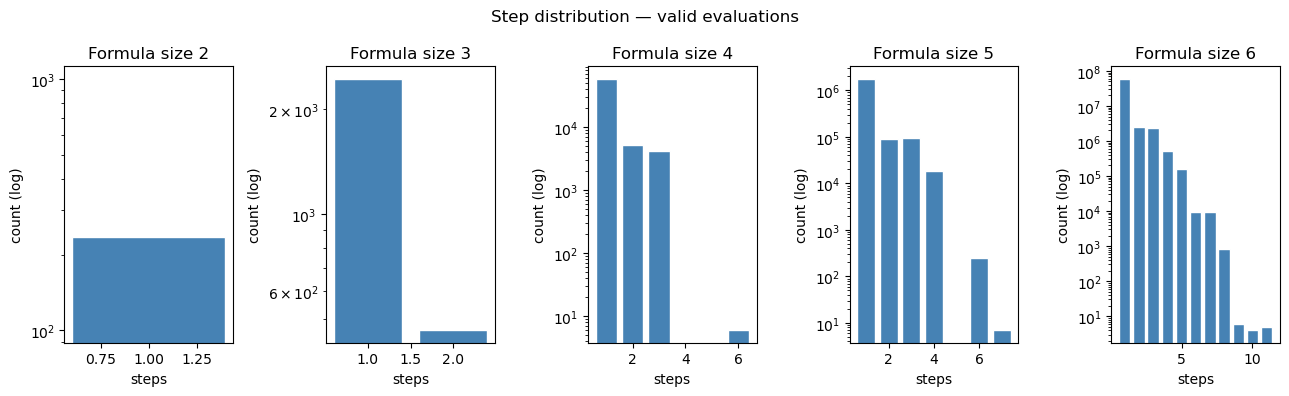

In [28]:
_step_dist = ddb.sql("""
    SELECT fsize, steps, COUNT(*) AS n FROM results
    WHERE valid
    GROUP BY fsize, steps ORDER BY fsize, steps
""").df()

_szs = sorted(_step_dist['fsize'].unique())
fig, axes = plt.subplots(1, len(_szs), figsize=(13, 4), sharey=False)
if len(_szs) == 1:
    axes = [axes]
for ax, _sz in zip(axes, _szs):
    _sub = _step_dist[_step_dist['fsize'] == _sz]
    ax.bar(_sub['steps'], _sub['n'], color='steelblue', edgecolor='white', width=0.8)
    ax.set_yscale('log')
    ax.set_title(f'Formula size {_sz}')
    ax.set_xlabel('steps')
    ax.set_ylabel('count (log)')
plt.suptitle('Step distribution — valid evaluations')
plt.tight_layout()
plt.show()

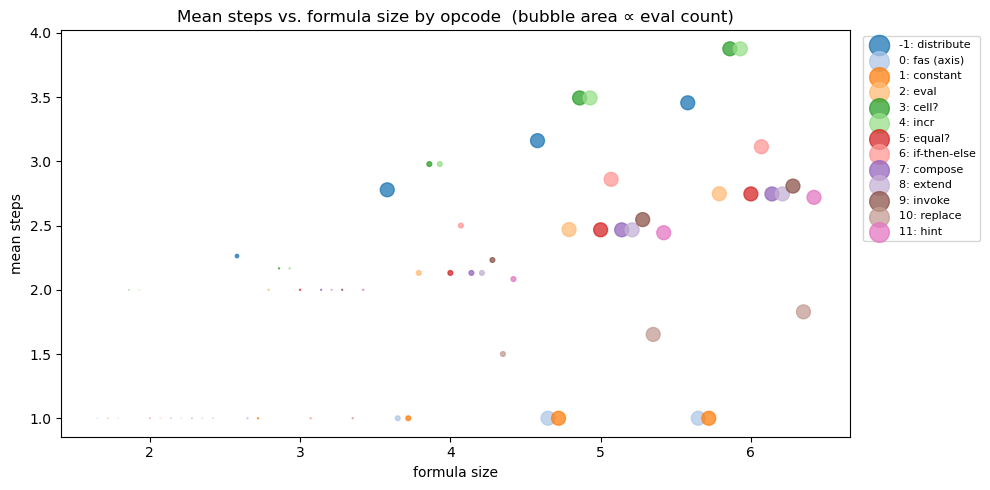

In [29]:
# With large result sets scatter-plotting individual evals is infeasible;
# aggregate to mean steps per (fsize, opcode) and size bubbles by eval count.
_agg = ddb.sql("""
    SELECT fsize, opcode,
           AVG(steps)  AS mean_steps,
           MAX(steps)  AS max_steps,
           COUNT(*)    AS n
    FROM results
    GROUP BY fsize, opcode ORDER BY fsize, opcode
""").df()
_agg['opcode'] = _agg['opcode'].astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
_colors = plt.cm.tab20.colors
for _i, _opc in enumerate(sorted(_agg['opcode'].unique())):
    _sub = _agg[_agg['opcode'] == _opc]
    _jitter = 0.07 * (int(_opc) - 5)
    ax.scatter(
        _sub['fsize'] + _jitter, _sub['mean_steps'],
        s=(_sub['n'].clip(upper=5e5) / 5e3),
        color=_colors[int(_i) % len(_colors)],
        alpha=0.75,
        label=f'{_opc}: {OPC_NAMES.get(_opc, "?")}',
    )
ax.set_xlabel('formula size')
ax.set_ylabel('mean steps')
ax.set_title('Mean steps vs. formula size by opcode  (bubble area ∝ eval count)')
ax.legend(markerscale=2, bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

## 6. Targeted Next-Size Deep Dive

Explores size `max(SWEEP_SIZES) + 1` formulas — one level deeper than the full sweep.
Restricted to shapes whose root's left child is a leaf (so the head atom is the opcode),
opcodes 6–9 only, and subject fixed to `0`, to keep the eval count tractable.

In [1]:
_TARGET_SIZE  = max(SWEEP_SIZES) + 1
_TARGET_OPCS  = {6, 7, 8, 9}
_sizeN_shapes = list(all_shapes(_TARGET_SIZE))
# Keep only shapes where the root's left child is a leaf (head = opcode atom).
_target_shapes = [(i, s) for i, s in enumerate(_sizeN_shapes) if s[0] is None]
_n_rest  = _TARGET_SIZE - 1          # leaves excluding the opcode leaf
_total_N = len(_target_shapes) * len(_TARGET_OPCS) * len(ATOM_RANGE) ** _n_rest
print(f'Target size: {_TARGET_SIZE}')
print(f'Shapes with atom head: {len(_target_shapes)} of {len(_sizeN_shapes)}')
print(f'Targeted evals: {_total_N:,}  (ATOM_RANGE len={len(ATOM_RANGE)})')

NameError: name 'SWEEP_SIZES' is not defined

In [ ]:
_save_targeted = f"nock_targeted_size{_TARGET_SIZE}_a{len(ATOM_RANGE)}.parquet"
_writer_t = pq.ParquetWriter(_save_targeted, _SCHEMA)
_rows_t   = []
_written_t = 0

def _flush_t():
    global _written_t
    if not _rows_t:
        return
    arrays = {k: [r[k] for r in _rows_t] for k in _SCHEMA.names}
    _writer_t.write_table(pa.table(arrays, schema=_SCHEMA))
    _written_t += len(_rows_t)
    _rows_t.clear()

pbar_t = tqdm(total=_total_N, desc=f'size {_TARGET_SIZE} targeted')
try:
    for _shape_idx, _shape in _target_shapes:
        for _opc in sorted(_TARGET_OPCS):
            for _rest in itertools.product(ATOM_RANGE, repeat=_n_rest):
                _atoms   = (_opc,) + _rest
                _formula = _fill(_shape, iter(_atoms))
                _result, _steps, _error = nock_counted(0, _formula)
                if _result is not None:
                    _rtype  = 'atom' if not deep(_result) else 'cell'
                    _rsize  = noun_size(_result)
                    _rdepth = noun_depth(_result)
                    _rstr   = noun_str(_result)
                else:
                    _rtype, _rsize, _rdepth, _rstr = 'crash', 0, 0, ''
                _rows_t.append({
                    'subject': '0',
                    'stype':   'atom',
                    'formula': noun_str(_formula),
                    'fsize':   _TARGET_SIZE,
                    'fshape':  _shape_idx,
                    'opcode':  _opc,
                    'valid':   _error is None,
                    'error':   _error or '',
                    'rtype':   _rtype,
                    'rsize':   _rsize,
                    'rdepth':  _rdepth,
                    'result':  _rstr,
                    'steps':   _steps,
                })
                if len(_rows_t) >= CHUNK_SIZE:
                    _flush_t()
                pbar_t.update(1)
    _flush_t()
finally:
    _writer_t.close()
    pbar_t.close()

print(f'\nWrote {_written_t:,} rows -> {_save_targeted}')
df_t = pd.read_parquet(_save_targeted)
df_t.groupby(['opcode', 'valid'])['steps'].agg(['count', 'mean', 'max']).round(2)

size 7 targeted: 100%|████████| 501645312/501645312 [57:53<00:00, 144416.69it/s]



Wrote 501,645,312 rows -> nock_targeted_size7_a12.parquet


In [ ]:
print(f'Top 15 by step count (size-{_TARGET_SIZE} targeted, subject=0):')
print(
    df_t.nlargest(15, 'steps')
    [['formula', 'opcode', 'steps', 'valid', 'rtype', 'rsize', 'rdepth', 'result']]
    .to_string(index=False)
)

print(f'\nValidity rate by opcode (size-{_TARGET_SIZE} targeted):')
print(
    df_t.groupby('opcode')['valid']
    .agg(total='count', valid_n='sum')
    .assign(pct=lambda x: round(100 * x['valid_n'] / x['total'], 1))
    .to_string()
)